### Imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

### Load Features

In [2]:
import numpy as np

# Load extracted features
X = np.load("../models/X_features.npy")

# Load labels
y = np.load("../models/y_labels.npy")

print("X shape :", X.shape)
print("y shape :", y.shape)

X shape : (6652, 26756)
y shape : (6652,)


### Feature Scaling

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### PCA (Dimensionality Reduction)

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=300)

X_pca = pca.fit_transform(X_scaled)

print("PCA shape :", X_pca.shape)

PCA shape : (6652, 300)


### Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### KNN

In [7]:
# =====================================
# KNN CLASSIFIER
# =====================================

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

knn_acc = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy :", knn_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy : 0.5657400450788881

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.50      0.61       200
           1       0.58      0.42      0.49       200
           2       0.50      0.23      0.31        31
           3       0.60      0.14      0.23       200
           4       0.90      0.56      0.69       382
           5       0.42      1.00      0.59       318

    accuracy                           0.57      1331
   macro avg       0.63      0.48      0.49      1331
weighted avg       0.67      0.57      0.55      1331



### SVM

In [9]:
# =====================================
# SVM CLASSIFIER
# =====================================

svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy :", svm_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy : 0.8287002253944402

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.88      0.88       200
           1       0.72      0.77      0.74       200
           2       1.00      0.13      0.23        31
           3       0.82      0.63      0.71       200
           4       0.80      0.86      0.83       382
           5       0.91      0.98      0.95       318

    accuracy                           0.83      1331
   macro avg       0.85      0.71      0.72      1331
weighted avg       0.83      0.83      0.82      1331



### Decision Tree

In [8]:
# =====================================
# DECISION TREE
# =====================================

dt = DecisionTreeClassifier(
    max_depth=20,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy :", dt_acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy : 0.6123215627347859

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.58      0.59       200
           1       0.38      0.39      0.38       200
           2       0.08      0.10      0.09        31
           3       0.48      0.41      0.44       200
           4       0.66      0.68      0.67       382
           5       0.83      0.87      0.85       318

    accuracy                           0.61      1331
   macro avg       0.51      0.50      0.50      1331
weighted avg       0.61      0.61      0.61      1331



### ANN

In [10]:
# =====================================
# ANN MODEL
# =====================================

ann = Sequential([

    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),

    Dropout(0.3),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(6, activation='softmax')

])

ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = ann.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32
)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4182 - loss: 1.9521 - val_accuracy: 0.6629 - val_loss: 0.9782
Epoch 2/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6259 - loss: 0.9985 - val_accuracy: 0.7286 - val_loss: 0.7238
Epoch 3/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7091 - loss: 0.7830 - val_accuracy: 0.7700 - val_loss: 0.6293
Epoch 4/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7639 - loss: 0.6209 - val_accuracy: 0.7812 - val_loss: 0.6070
Epoch 5/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7982 - loss: 0.5205 - val_accuracy: 0.7915 - val_loss: 0.5971
Epoch 6/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8292 - loss: 0.4453 - val_accuracy: 0.8028 - val_loss: 0.5607
Epoch 7/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8597 - loss: 0.3738 - val_accuracy: 0.8085 - val_loss: 0.5573
Epoch 8/20
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8778 - loss: 0.3234 - val_accuracy: 0

### ANN Evaluation

In [11]:
# =====================================
# ANN EVALUATION
# =====================================

ann_loss, ann_acc = ann.evaluate(X_test, y_test)

print("ANN Accuracy :", ann_acc)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8047 - loss: 0.8250
ANN Accuracy : 0.8046581745147705


### Compare Models

In [12]:
# =====================================
# MODEL COMPARISON
# =====================================

results = pd.DataFrame({

    "Model": [
        "KNN",
        "SVM",
        "Decision Tree",
        "ANN"
    ],

    "Accuracy": [
        knn_acc,
        svm_acc,
        dt_acc,
        ann_acc
    ]

})

results

,Model,Accuracy
0,KNN,0.565740
1,SVM,0.828700
2,Decision Tree,0.612322
3,ANN,0.804658


### Visualization

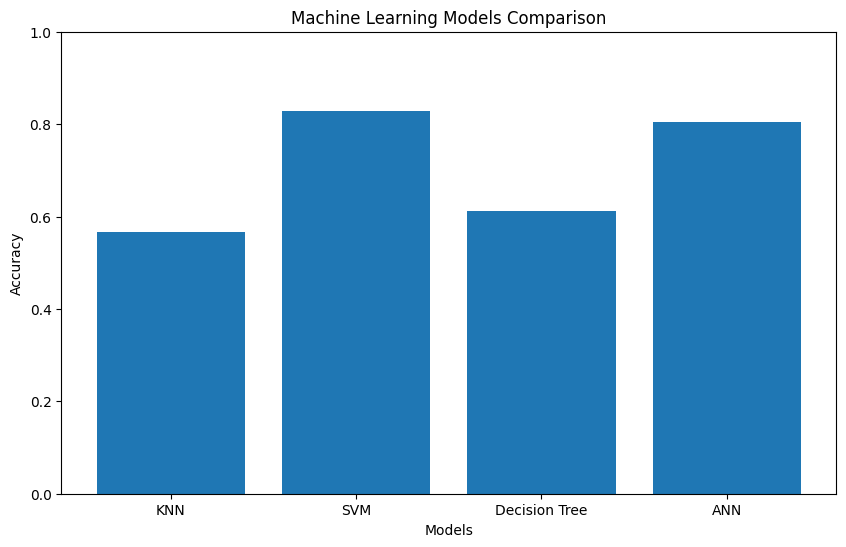

In [13]:
# =====================================
# ACCURACY COMPARISON
# =====================================

plt.figure(figsize=(10,6))

plt.bar(results["Model"], results["Accuracy"])

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Machine Learning Models Comparison")

plt.ylim(0,1)

plt.show()

### Best Model

In [14]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("Best Model :")
print(best_model)

Best Model :
Model          SVM
Accuracy    0.8287
Name: 1, dtype: object
